## Fase 2: Uso de canteranos por temporada

Este notebook cruza la lista de canteranos del Barça (recolectada de Wikipedia) con los datos de apariciones por jugador y temporada de Transfermarkt, para medir el uso de jugadores formados en la cantera a lo largo de las 33 temporadas del proyecto.

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import pearsonr

appearances = pd.read_csv('../data/raw/transfermarkt/appearances.csv')
print(appearances.shape)
print(appearances.columns.tolist())
appearances.head(10)

(1894350, 13)
['appearance_id', 'game_id', 'player_id', 'player_club_id', 'player_current_club_id', 'date', 'player_name', 'competition_id', 'yellow_cards', 'red_cards', 'goals', 'assists', 'minutes_played']


,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2231978_38004,2231978,38004,853,235,2012-07-03,Aurélien Joachim,CLQ,0,0,2,0,90
1,2233748_79232,2233748,79232,8841,2698,2012-07-05,Ruslan Abyshov,ELQ,0,0,0,0,90
2,2234413_42792,2234413,42792,6251,465,2012-07-05,Sander Puri,ELQ,0,0,0,0,45
3,2234418_73333,2234418,73333,1274,76,2012-07-05,Vegar Hedenstad,ELQ,0,0,0,0,90
4,2234421_122011,2234421,122011,195,3008,2012-07-05,Markus Henriksen,ELQ,0,0,0,1,90
5,2234421_146889,2234421,146889,195,2778,2012-07-05,Peter Ankersen,ELQ,1,0,0,0,90
6,2235539_28716,2235539,28716,282,7185,2012-07-05,Adi Adilovic,ELQ,0,0,0,0,90
7,2235539_69445,2235539,69445,282,19771,2012-07-05,Ivan Sesar,ELQ,1,0,0,1,90
8,2235545_19409,2235545,19409,317,200,2012-07-05,Willem Janssen,ELQ,0,0,0,0,45
9,2235545_30003,2235545,30003,317,317,2012-07-05,Wout Brama,ELQ,0,0,0,0,90


In [52]:
print(131 in appearances['player_club_id'].values)
print(118 in appearances['player_club_id'].values)

True
False


In [53]:
games = pd.read_csv('../data/raw/transfermarkt/games.csv')
print(games.shape)
print(games.columns.tolist())
games.head(3)

(88958, 23)
['game_id', 'competition_id', 'season', 'round', 'date', 'home_club_id', 'away_club_id', 'home_club_goals', 'away_club_goals', 'home_club_position', 'away_club_position', 'home_club_manager_name', 'away_club_manager_name', 'stadium', 'attendance', 'referee', 'url', 'home_club_formation', 'away_club_formation', 'home_club_name', 'away_club_name', 'aggregate', 'competition_type']


,game_id,competition_id,season,round,date,home_club_id,away_club_id,home_club_goals,away_club_goals,home_club_position,...,stadium,attendance,referee,url,home_club_formation,away_club_formation,home_club_name,away_club_name,aggregate,competition_type
0,1026846,FIWC,2009,Round of 16,2010-06-26,3449,3589,2,1,NaN,...,Nelson Mandela Bay Stadium,30597.0,Wolfgang Stark,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,Uruguay,South Korea,2:1,national_team_competition
1,1026847,FIWC,2009,Round of 16,2010-06-27,3437,6303,3,1,NaN,...,FNB-Stadium,84377.0,Roberto Rosetti,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,Argentina,Mexico,3:1,national_team_competition
2,1027001,FIWC,2009,Round of 16,2010-06-26,3505,3441,1,2,NaN,...,Royal Bafokeng Stadium,34976.0,Viktor Kassai,https://www.transfermarkt.co.uk/spielbericht/i...,NaN,NaN,United States,Ghana,1:2,national_team_competition


In [54]:
print(games['competition_id'].unique()[:20])
print('ES1' in games['competition_id'].values)

['FIWC' 'EURO' 'NLSC' 'SCI' 'BESC' 'USC' 'DFB' 'ELQ' 'L1' 'RU1' 'UKR1'
 'FR1' 'DK1' 'BE1' 'GB1' 'SC1' 'DFL' 'CLQ' 'UKRS' 'UKRP']
True


In [55]:
games_laliga = games[games['competition_id'] == 'ES1'].copy()
print(games_laliga.shape)
print(games_laliga['season'].unique())

(5320, 23)
[2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]


In [56]:
print(games['season'].min(), games['season'].max())
print(games[games['competition_id'] == 'ES1']['season'].value_counts().sort_index())

2005 2025
season
2012    380
2013    380
2014    380
2015    380
2016    380
2017    380
2018    380
2019    380
2020    380
2021    380
2022    380
2023    380
2024    380
2025    380
Name: count, dtype: int64


## Fase 2: Uso de canteranos por temporada

Este notebook cruza la lista de canteranos del Barça (recolectada de Wikipedia, `canteranos_wikipedia.csv`) con los datos de apariciones y minutos jugados por jugador y temporada de Transfermarkt (`appearances.csv`, `games.csv`), para medir qué porcentaje de los minutos jugados por el Barça en La Liga corresponden a jugadores formados en La Masía.

**Limitación de cobertura:** a diferencia de `transfers.csv` (con historia manual complementaria hasta 1993/94), los datos de partido a partido de Transfermarkt (`appearances.csv`/`games.csv`) solo cubren La Liga desde la temporada 2012/13 en adelante. No existe una fuente gratuita y confiable con este nivel de detalle (minutos por jugador y partido) para temporadas anteriores, y reconstruirlo a mano no es viable dado el volumen de datos que implicaría.

**Alcance de este análisis:** el porcentaje de minutos de canteranos se calcula únicamente para las 14 temporadas con datos disponibles (2012/13-2025/26). Para el resto del rango del proyecto (1993/94-2011/12), no se calcula esta métrica de forma cuantitativa; se documenta esta limitación explícitamente en vez de aproximarla con un proxy de menor calidad (como un simple conteo de canteranos en plantilla), que mediría algo distinto (presencia, no intensidad de uso) y no sería comparable con el resto del análisis.

In [57]:
apariciones_liga = appearances.merge(
    games_laliga[['game_id', 'season']],
    on='game_id',
    how='inner'
)

apariciones_barca = apariciones_liga[apariciones_liga['player_club_id'] == 131].copy()

apariciones_barca['temporada'] = apariciones_barca['season'].apply(lambda s: f'{str(s)[2:]}{str(s+1)[2:]}')

In [58]:
canteranos = pd.read_csv('../data/raw/canteranos_wikipedia.csv')

apariciones_barca['es_canterano'] = apariciones_barca['player_name'].isin(canteranos['nombre'])

print(apariciones_barca['es_canterano'].value_counts())

es_canterano
False    4566
True     3019
Name: count, dtype: int64


In [59]:
nombres_encontrados = apariciones_barca[apariciones_barca['es_canterano']]['player_name'].unique()
print(len(nombres_encontrados), 'de', len(canteranos))

canteranos_no_encontrados = canteranos[~canteranos['nombre'].isin(nombres_encontrados)]
print(canteranos_no_encontrados[['nombre', 'anio_inicio_carrera']].to_string(index=False))

39 de 103
            nombre  anio_inicio_carrera
     Ángel Pedraza                 1980
             Nayim                 1986
    Esteve Fradera                 1985
     Jordi Vinyals                 1987
 Cristóbal Parralo                 1987
        Luis Milla                 1988
   Carlos Busquets                 1988
    Guillermo Amor                 1988
       Jordi Roura                 1988
       Sergi López                 1988
        José Serer                 1988
     Albert Ferrer                 1988
      Óscar García                 1990
   Josep Guardiola                 1990
        Paqui Veza                 1990
   Antonio Pinilla                 1990
     Tito Vilanova                 1992
      Toni Jiménez                 1992
    Lluís Carreras                 1993
     Sergi Barjuan                 1993
     Luis Cembrano                 1994
      Jordi Cruyff                 1994
  Francisco Rufete                 1994
    Toni Velamazán            

In [60]:
sospechosos = ['Alejandro Grimaldo', 'André Onana', 'Marc Cucurella', 'Juan Miranda', 'Ronald Araújo', 'Èric García']

for nombre in sospechosos:
    apellido = nombre.split()[-1]
    coincidencias = apariciones_barca[apariciones_barca['player_name'].str.contains(apellido, case=False, na=False)]['player_name'].unique()
    print(nombre, '->', coincidencias)

Alejandro Grimaldo -> []
André Onana -> []
Marc Cucurella -> []
Juan Miranda -> []
Ronald Araújo -> []
Èric García -> ['Eric García' 'Joan García']


In [61]:
print(apariciones_barca[apariciones_barca['player_name'].str.contains('rau', case=False, na=False)]['player_name'].unique())

print(canteranos[canteranos['nombre'].str.contains('Onana', case=False, na=False)])

['Ronald Araujo']
         nombre  nacimiento    carrera  partidos_totales_carrera  \
79  André Onana        1996  2015-Act.                       374   

    goles_totales_carrera        primer_club              ultimo_club  estado  \
79                    NaN  Ajax de Ámsterdam  Manchester United F. C.  Activo   

    anio_inicio_carrera nombre_normalizado  
79                 2015        andre onana  


In [62]:
from unidecode import unidecode

In [63]:
apariciones_barca['nombre_normalizado'] = apariciones_barca['player_name'].apply(lambda x: unidecode(str(x)).lower())
canteranos['nombre_normalizado'] = canteranos['nombre'].apply(lambda x: unidecode(str(x)).lower())

apariciones_barca['es_canterano'] = apariciones_barca['nombre_normalizado'].isin(canteranos['nombre_normalizado'])
print(apariciones_barca['es_canterano'].value_counts())

es_canterano
False    4308
True     3277
Name: count, dtype: int64


In [64]:
nombres_encontrados = apariciones_barca[apariciones_barca['es_canterano']]['nombre_normalizado'].unique()
canteranos_no_encontrados = canteranos[~canteranos['nombre_normalizado'].isin(nombres_encontrados)]
print(len(canteranos_no_encontrados), 'sin coincidencia, de', len(canteranos))
print(canteranos_no_encontrados[canteranos_no_encontrados['anio_inicio_carrera'] >= 2012][['nombre', 'anio_inicio_carrera']].to_string(index=False))

62 sin coincidencia, de 103
            nombre  anio_inicio_carrera
 Patricio Gabarrón                 2012
Alejandro Grimaldo                 2015
       André Onana                 2015
    Marc Cucurella                 2017
      Juan Miranda                 2018


In [65]:
print(apariciones_barca[apariciones_barca['player_name'].str.contains('avi', case=False, na=False)]['player_name'].unique())
print(apariciones_barca[apariciones_barca['player_name'].str.contains('abarr', case=False, na=False)]['player_name'].unique())

['Javier Mascherano' 'Xavi' 'David Villa' 'Gavi' 'Xavi Espart']
[]


In [66]:
canteranos.loc[canteranos['nombre'] == 'Pablo Páez Gavira Gavi', 'nombre'] = 'Gavi'
canteranos['nombre_normalizado'] = canteranos['nombre'].apply(lambda x: unidecode(str(x)).lower())

apariciones_barca['es_canterano'] = apariciones_barca['nombre_normalizado'].isin(canteranos['nombre_normalizado'])
print(apariciones_barca['es_canterano'].value_counts())

canteranos.to_csv('../data/raw/canteranos_wikipedia.csv', index=False)

es_canterano
False    4308
True     3277
Name: count, dtype: int64


### Cruce de canteranos con apariciones en La Liga (2012/13-2025/26)

Se cruzó la lista de 103 canteranos de Wikipedia contra `appearances.csv` de Transfermarkt, normalizando tildes con `unidecode` para evitar falsos negativos por diferencias de formato entre fuentes (ej. "Araújo" vs "Araujo").

**Correcciones aplicadas:** un nombre (Gavi) se registró con nombre completo en Wikipedia pero aparece como apodo en Transfermarkt, corregido manualmente.

**Casos legítimamente sin coincidencia (verificados, no son errores de datos):** Alejandro Grimaldo, Marc Cucurella, Juan Miranda, André Onana y Patricio Gabarrón pasaron por la cantera pero no sumaron minutos en La Liga con el primer equipo del Barça dentro del rango 2012/13-2025/26 (salidas cedidas, debut limitado a otras competiciones, o formación que no llegó a consolidarse en el primer equipo). Esto confirma que la lista de Wikipedia incluye jugadores formados en La Masía en sentido amplio, no solo a quienes debutaron con el primer equipo en Liga.

In [67]:
minutos_temporada = apariciones_barca.groupby(['temporada', 'es_canterano'])['minutes_played'].sum().reset_index()

uso_cantera = minutos_temporada.pivot(index='temporada', columns='es_canterano', values='minutes_played').fillna(0)
uso_cantera.columns = ['minutos_no_cantera', 'minutos_cantera']
uso_cantera['minutos_totales'] = uso_cantera['minutos_no_cantera'] + uso_cantera['minutos_cantera']
uso_cantera['porcentaje_cantera'] = uso_cantera['minutos_cantera'] / uso_cantera['minutos_totales']

uso_cantera = uso_cantera.reset_index().sort_values('temporada')
uso_cantera

,temporada,minutos_no_cantera,minutos_cantera,minutos_totales,porcentaje_cantera
0,1213,15360,22161,37521,0.590629
1,1314,17879,19733,37612,0.524646
2,1415,22617,14913,37530,0.397362
3,1516,20933,16683,37616,0.443508
4,1617,24140,13456,37596,0.357910
5,1718,22016,15546,37562,0.413876
6,1819,22786,14392,37178,0.387111
7,1920,22132,15411,37543,0.410489
8,2021,15893,12692,28585,0.444009
9,2122,19518,17247,36765,0.469115


In [68]:
top_canteranos = apariciones_barca[apariciones_barca['es_canterano']].groupby('player_name')['minutes_played'].sum().sort_values(ascending=False).head(20)
top_canteranos

player_name
Sergio Busquets    28881
Lionel Messi       25673
Gerard Piqué       24725
Jordi Alba         22572
Sergi Roberto      15247
Andrés Iniesta     11597
Ronald Araujo       9630
Alejandro Balde     8210
Eric García         7800
Gavi                7471
Lamine Yamal        7337
Pau Cubarsí         6889
Víctor Valdés       5063
Cesc Fàbregas       4786
Fermín López        4487
Marc Bartra         3514
Ansu Fati           3454
Dani Olmo           3293
Gerard Martín       3150
Martín Montoya      2860
Name: minutes_played, dtype: int64

### Nota metodológica: qué cuenta como "canterano" en este análisis

La definición de "canterano" no es unívoca en el mundo del fútbol. No existe un nivel mínimo de categoría inferior universalmente aceptado para aplicar la etiqueta: para algunos, solo cuenta quien pasó por las categorías más jóvenes del club (infantil, cadete, en el sistema español); para otros, cualquier etapa de formación cuenta, incluyendo el filial (Barça B / Barça Atlètic), aunque el jugador haya llegado a esa etapa ya como fichaje externo formado en otro club.

Este proyecto usa el criterio de la tabla "Jugadores formados en La Masía" de Wikipedia, que aplica la definición más amplia (incluye el filial como parte de la formación). Un ejemplo concreto dentro del dataset: Ronald Araújo llegó directamente al Barça Atlètic como fichaje, sin pasar por categorías más jóvenes del club, y bajo esta definición cuenta como canterano.

Se documenta esta decisión explícitamente para que cualquier lectura de "% de minutos de cantera" en este proyecto se entienda bajo la definición amplia usada, no como un estándar universal.

In [69]:
partidos_por_temporada = apariciones_barca.groupby('temporada')['game_id'].nunique()
print(partidos_por_temporada)

temporada
1213    38
1314    38
1415    38
1516    38
1617    38
1718    38
1819    38
1920    38
2021    38
2122    38
2223    38
2324    38
2425    38
2526    38
Name: game_id, dtype: int64


In [70]:
apariciones_2021 = apariciones_barca[apariciones_barca['temporada'] == '2021']

print('Total apariciones:', len(apariciones_2021))
print('Con minutos nulos:', apariciones_2021['minutes_played'].isna().sum())
print()

apariciones_1920 = apariciones_barca[apariciones_barca['temporada'] == '1920']
print('Comparación, apariciones en 19/20:', len(apariciones_1920))

Total apariciones: 473
Con minutos nulos: 0

Comparación, apariciones en 19/20: 541


### Limitación de cobertura: temporada 2020/21

La temporada 2020/21 muestra un total de minutos jugados notablemente menor (28,585) que el resto del rango (~37,500 en promedio), pese a tener los 38 partidos de liga completos registrados. La causa es un menor número de apariciones individuales capturadas por Transfermarkt para esa temporada específica (473, contra 541 de la temporada anterior), sin que existan valores nulos en `minutes_played` que expliquen la diferencia. Es la misma temporada ya identificada como atípica por la pandemia (jugada sin público), y es posible que la cobertura de datos de esa ventana particular sea menos completa en la fuente por motivos ajenos al proyecto. El `porcentaje_cantera` de esa temporada se mantiene en el análisis, pero debe leerse con esta salvedad de cobertura, no como directamente comparable en precisión al resto de temporadas.

In [71]:
uso_cantera.to_csv('../data/processed/uso_cantera_temporada.csv', index=False)

In [72]:
df_maestro = pd.read_csv('../data/processed/df_maestro.csv', dtype={'temporada': str})

In [73]:
uso_cantera['temporada'] = uso_cantera['temporada'].astype(str)
uso_cantera = uso_cantera.merge(df_maestro[['temporada', 'anio_inicio', 'entrenador_principal', 'rendimiento_relativo']], on='temporada')
uso_cantera = uso_cantera.sort_values('anio_inicio')
uso_cantera

,temporada,minutos_no_cantera,minutos_cantera,minutos_totales,porcentaje_cantera,anio_inicio,entrenador_principal,rendimiento_relativo
0,1213,15360,22161,37521,0.590629,2012,Tito Vilanova,0.877193
1,1314,17879,19733,37612,0.524646,2013,Gerardo Martino,0.763158
2,1415,22617,14913,37530,0.397362,2014,Luis Enrique,0.824561
3,1516,20933,16683,37616,0.443508,2015,Luis Enrique,0.798246
4,1617,24140,13456,37596,0.357910,2016,Luis Enrique,0.789474
5,1718,22016,15546,37562,0.413876,2017,Ernesto Valverde,0.815789
6,1819,22786,14392,37178,0.387111,2018,Ernesto Valverde,0.763158
7,1920,22132,15411,37543,0.410489,2019,Ernesto Valverde,0.719298
8,2021,15893,12692,28585,0.444009,2020,Ronald Koeman,0.692982
9,2122,19518,17247,36765,0.469115,2021,Ronald Koeman,0.640351


In [74]:
def formato_temporada(x, pos):
    inicio = int(x)
    fin = (inicio + 1) % 100
    return f'{inicio}/{fin:02d}'

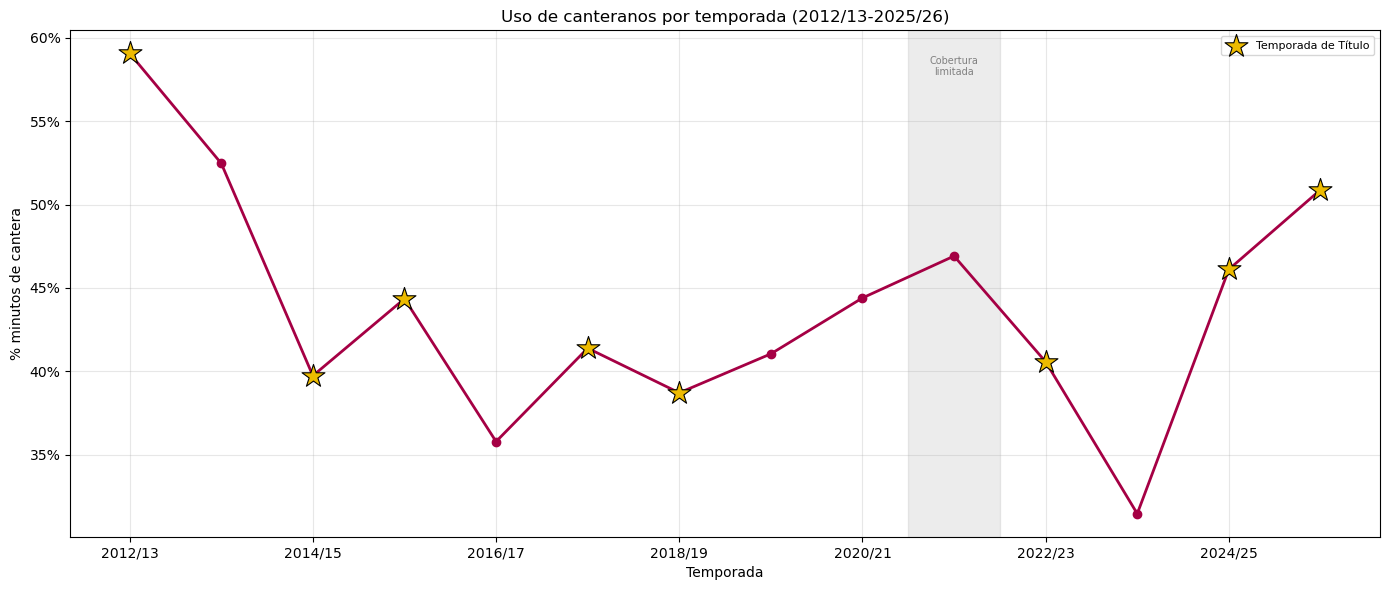

In [75]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(uso_cantera['anio_inicio'], uso_cantera['porcentaje_cantera'], marker='o', color='#a50044', linewidth=2)

titulos_cantera = uso_cantera[uso_cantera['temporada'].isin(df_maestro[df_maestro['categoria_temporada'] == 'Título']['temporada'])]
ax.scatter(titulos_cantera['anio_inicio'], titulos_cantera['porcentaje_cantera'], marker='*', s=300,
            color='#edbb00', edgecolor='black', linewidth=0.8, zorder=4, label='Temporada de Título')

ax.axvspan(2020.5, 2021.5, color='gray', alpha=0.15, zorder=0)
ax.text(2021, 0.95, 'Cobertura\nlimitada', transform=ax.get_xaxis_transform(),
        fontsize=7, ha='center', va='top', color='gray')

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.xaxis.set_major_formatter(FuncFormatter(formato_temporada))
ax.set_xlabel('Temporada')
ax.set_ylabel('% minutos de cantera')
ax.set_title('Uso de canteranos por temporada (2012/13-2025/26)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig('../reports/figures/uso_cantera_temporada.png', dpi=150, bbox_inches='tight')
plt.show()

In [79]:
correlacion_cantera, p_cantera = pearsonr(uso_cantera['porcentaje_cantera'], uso_cantera['rendimiento_relativo'])
print(f'Uso de cantera vs rendimiento: r={correlacion_cantera:.3f}, p={p_cantera:.3f}')

Uso de cantera vs rendimiento: r=0.274, p=0.344


In [80]:
cantera_entrenador = uso_cantera.groupby('entrenador_principal').agg(
    temporadas=('temporada', 'count'),
    porcentaje_cantera_promedio=('porcentaje_cantera', 'mean')
).reset_index().sort_values('porcentaje_cantera_promedio', ascending=False)

cantera_entrenador

,entrenador_principal,temporadas,porcentaje_cantera_promedio
5,Tito Vilanova,1,0.590629
1,Gerardo Martino,1,0.524646
2,Hansi Flick,2,0.484978
4,Ronald Koeman,2,0.456562
0,Ernesto Valverde,3,0.403825
3,Luis Enrique,3,0.399594
6,Xavi Hernández,2,0.360190


In [81]:
uso_cantera[uso_cantera['entrenador_principal'] == 'Xavi Hernández'][['temporada', 'porcentaje_cantera']]

,temporada,porcentaje_cantera
10,2223,0.40572
11,2324,0.31466


### Uso de cantera y títulos, por entrenador (2+ temporadas en el rango 2012/13-2025/26)

Se compara el porcentaje promedio de minutos de cantera de cada entrenador (solo los que dirigieron 2 o más temporadas dentro del rango con datos disponibles) contra cuántos títulos consiguieron en esas mismas temporadas, para ver si el uso de cantera acompaña o no al éxito deportivo.

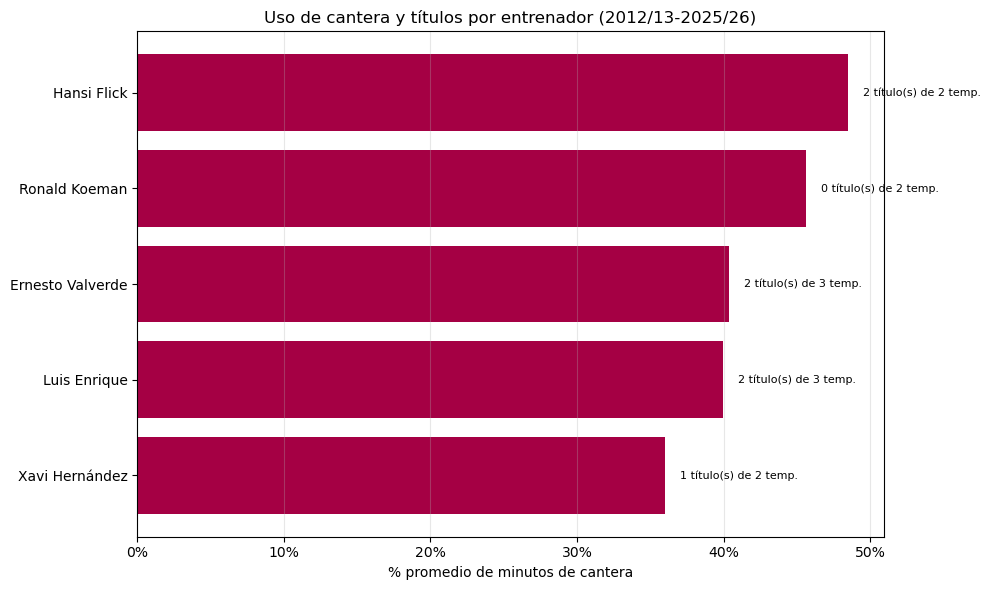

In [82]:
cantera_titulos = uso_cantera.merge(df_maestro[['temporada', 'categoria_temporada']], on='temporada')

entrenadores_2plus = cantera_entrenador[cantera_entrenador['temporadas'] >= 2]['entrenador_principal']

resumen_cantera_titulos = cantera_titulos[cantera_titulos['entrenador_principal'].isin(entrenadores_2plus)].groupby(
    'entrenador_principal'
).agg(
    temporadas=('temporada', 'count'),
    porcentaje_cantera_promedio=('porcentaje_cantera', 'mean'),
    titulos=('categoria_temporada', lambda x: (x == 'Título').sum())
).reset_index().sort_values('porcentaje_cantera_promedio')

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(resumen_cantera_titulos['entrenador_principal'], resumen_cantera_titulos['porcentaje_cantera_promedio'], color='#a50044')

for i, (pct, temp, tit) in enumerate(zip(
    resumen_cantera_titulos['porcentaje_cantera_promedio'],
    resumen_cantera_titulos['temporadas'],
    resumen_cantera_titulos['titulos']
)):
    ax.text(pct + 0.01, i, f'{tit} título(s) de {temp} temp.', va='center', fontsize=8)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
ax.set_xlabel('% promedio de minutos de cantera')
ax.set_title('Uso de cantera y títulos por entrenador (2012/13-2025/26)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
fig.savefig('../reports/figures/cantera_titulos_entrenador.png', dpi=150, bbox_inches='tight')
plt.show()

### Uso de cantera y títulos, por entrenador

El cruce entre uso de cantera y títulos conseguidos, dentro del grupo de entrenadores con 2+ temporadas en el rango 2012/13-2025/26, no muestra un patrón simple de "más cantera implica más títulos". El caso más claro en contra de esa narrativa es Ronald Koeman: segundo mayor uso de cantera del grupo (45.7%) y cero títulos en sus 2 temporadas, coincidiendo con la conocida crisis institucional de esa etapa. En el extremo opuesto, Hansi Flick combina el mayor uso de cantera (48.5%) con el mejor récord de títulos del grupo (2 de 2 temporadas), aunque con una muestra todavía chica para confirmar el patrón. Valverde y Luis Enrique, con niveles de cantera similares entre sí y la misma cantidad de temporadas, lograron también la misma cantidad de títulos, la única coincidencia clara entre ambas variables dentro del grupo.

En conjunto, esto refuerza la lectura estadística ya calculada (r=0.274, p=0.344, no significativa): el uso de cantera por sí solo no predice el éxito de una temporada, el contexto de cada etapa (crisis institucional, calidad de plantilla, situación financiera) sigue pesando más que la sola proporción de minutos jugados por formados en casa.

### Reflexión (no es una conclusión del análisis)

A lo largo del proyecto, un patrón se repite: ni el gasto (r=0.227, no significativo) ni el uso de cantera (r=0.274, no significativo) predicen el rendimiento por sí solos, pero el entrenador sí muestra diferencias consistentes y más marcadas en cada análisis. Casos como Flick (alto uso de cantera, 2/2 títulos) frente a Koeman (uso de cantera similar, 0 títulos) sugieren que, dado que el Barça cuenta de forma prácticamente constante con cantera de calidad, capacidad de fichaje y respaldo institucional, **la variable que más parece diferenciar una etapa exitosa de una fallida es la calidad de las decisiones de quienes están al mando**, no la disponibilidad de recursos en sí.

Esto es una hipótesis, no un hallazgo demostrado. El entrenador es la única figura de mando que este proyecto analiza; una extensión natural sería incluir también a la directiva y presidencia del club (decisiones de fichajes, estructura deportiva, estabilidad institucional) como otra capa de "personas al mando", además del entrenador. Tampoco es algo que se pueda confirmar con datos de un solo club: haría falta comparar contra otros equipos con recursos similares para aislar si el patrón es específico del Barça o generalizable. Se documenta como línea de investigación futura (ver README), no como conclusión de este notebook.

### Mención honorífica: los canteranos con más minutos (2012/13-2025/26)

Sin ánimo de análisis adicional, un reconocimiento visual a los jugadores formados en La Masía con más minutos jugados en La Liga dentro del rango de datos disponible.

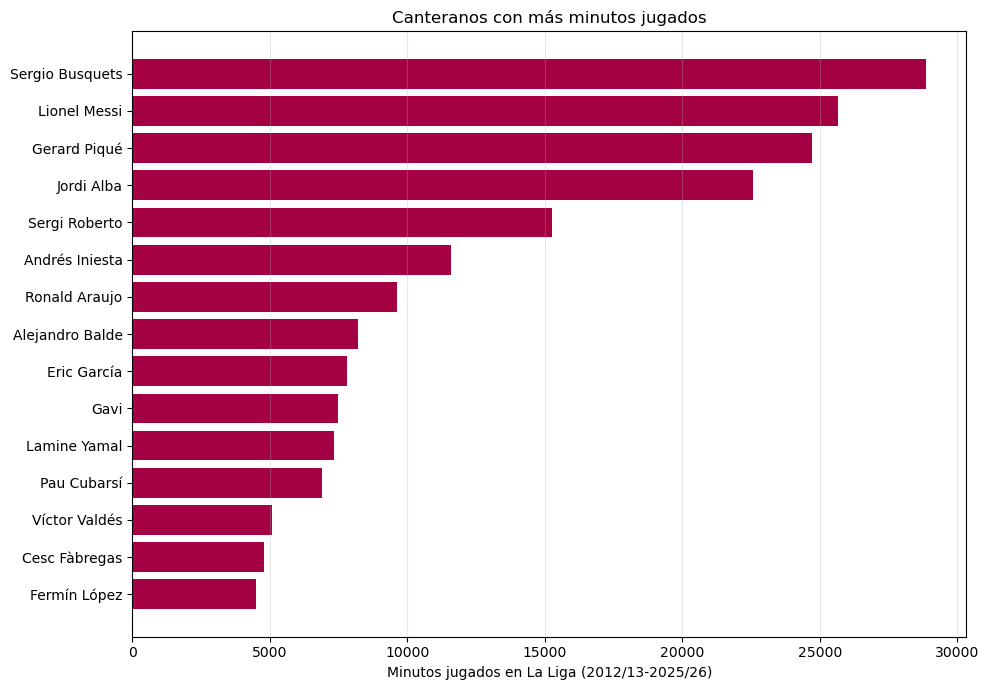

In [83]:
top15 = top_canteranos.head(15).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15.index, top15.values, color='#a50044')
ax.set_xlabel('Minutos jugados en La Liga (2012/13-2025/26)')
ax.set_title('Canteranos con más minutos jugados')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
fig.savefig('../reports/figures/top_canteranos_minutos.png', dpi=150, bbox_inches='tight')
plt.show()

## Fase 2: Uso de canteranos por temporada

Se cruzó la lista de 103 canteranos históricos del Barça (Wikipedia) con datos de apariciones y minutos jugados de Transfermarkt, para medir el porcentaje de minutos jugados en La Liga por jugadores formados en La Masía, por temporada.

**Limitación de cobertura:** los datos de partido a partido de Transfermarkt (`appearances.csv`/`games.csv`) solo cubren La Liga desde 2012/13 en adelante, así que este análisis se acota a 14 de las 33 temporadas del proyecto (2012/13-2025/26). No se aproximó el resto del rango con un proxy de menor calidad.

**Hallazgos:**
- El uso de cantera no predice el rendimiento de forma estadísticamente significativa (r=0.274, p=0.344), un patrón similar al del gasto neto en Fase 1.
- Tampoco hay una relación simple entre uso de cantera y títulos: Ronald Koeman tuvo el segundo mayor uso de cantera del grupo analizado (45.7%) sin ganar ningún título en sus 2 temporadas, mientras que Hansi Flick combinó el mayor uso de cantera (48.5%) con el mejor récord de títulos (2 de 2).
- El caso de Xavi Hernández (menor uso de cantera del grupo, 36%) se explica casi enteramente por la temporada 2023/24, la de menor uso de cantera de todo el rango, coincidiendo con la crisis financiera del club ya documentada en Fase 1.

**Reflexión (no un hallazgo demostrado):** el patrón repetido a lo largo del proyecto, donde ni gasto ni cantera predicen bien el rendimiento pero el entrenador sí muestra diferencias consistentes, sugiere una hipótesis: que la calidad de las decisiones de quienes están al mando pesa más que la disponibilidad de recursos, dado que el Barça cuenta de forma prácticamente constante con cantera de calidad y capacidad de fichaje. Esto no se puede confirmar con datos de un solo club, y queda como posible extensión futura del proyecto (Fase 4: incluir directiva y presidencia como otra capa de "personas al mando", comparando contra otros clubes con recursos similares).

**Entregable adicional (sin pretensión analítica):** un top 15 de los canteranos con más minutos jugados en el rango, como reconocimiento visual al linaje de La Masía, desde Busquets y Messi hasta la generación actual (Yamal, Cubarsí, Fermín López).

**Con esto, la Fase 2 del proyecto queda completa.**